In [1]:
%load_ext autoreload 
%autoreload 2
from xtr_estimator.logger import setup_logger

logger = setup_logger()

In [2]:
from dataset_configs import apply_config_myoglobin_general

config = apply_config_myoglobin_general("0.1ps")
config["map_processing"]["calculate_diffmap_before_f000"] = True



2026-04-20 14:57:51,827: xtr_estimator.logger: INFO: Imposing high_resolution_limit: 2.3 (processing.py:96)
2026-04-20 14:57:52,301: xtr_estimator.logger: INFO: Loading preprocessed maps from tmp/myo_0.1ps/myo_0.1ps/diffmap_23.0_tv_110.mtz (processing.py:251)
2026-04-20 14:57:52,311: xtr_estimator.logger: INFO: ignore_mask voxel count: 0.2712890625 (processing.py:305)
2026-04-20 14:57:52,312: xtr_estimator.logger: INFO: Shift value 0.32269 corresponds to zero frequency 20175.607 (processing.py:319)
2026-04-20 14:57:52,321: xtr_estimator.logger: WARNING: Diffmap Mean: -0.000000, Std: 0.019824 (370456701.py:10)
2026-04-20 14:57:52,325: xtr_estimator.logger: WARNING: Used threshold for posmask: 0.064, found 9 blobs (masking.py:182)
2026-04-20 14:57:52,325: xtr_estimator.logger: INFO: Using blobs with more than 7.370142836165655(3.0 A^3) voxels (masking.py:199)
2026-04-20 14:57:52,326: xtr_estimator.logger: INFO: Maximum Blob sizes found: 93 (masking.py:200)
2026-04-20 14:57:52,328: xtr_es

(<Figure size 640x480 with 2 Axes>,
 <Axes: xlabel='Difference Map $-\\Delta \\rho$ (standard deviations)', ylabel='Extrapolation factor $ \\chi^{-1} = -\\Delta\\rho/\\rho_{0}$'>,
 (np.float64(0.672186244617809), np.float64(0.1310570955200573)))

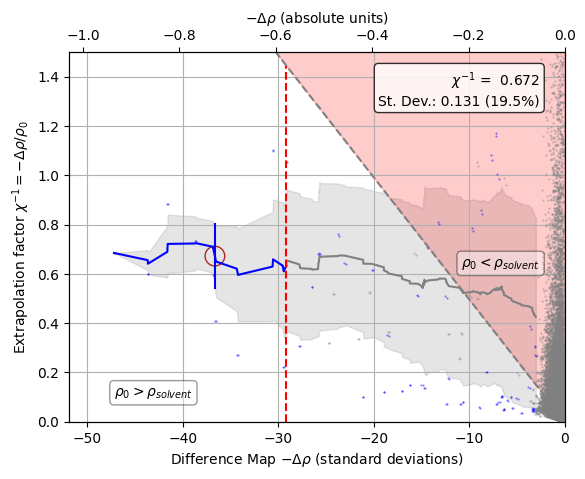

In [3]:

import copy 

from xtr_estimator.processing import get_maps, prepare_maps
from xtr_estimator.masking import make_inclusion_mask
from xtr_estimator.estimation import plot_extrapolation_estimate
unscaled_dark, unscaled_triggered = get_maps(config)
diffmap, map_dark, _ = prepare_maps(unscaled_dark, unscaled_triggered, config)

diffmap_np = diffmap.to_3d_numpy_map(map_sampling=config["general"]["map_sampling"])
logger.warning(
    f"Diffmap Mean: {diffmap_np.mean():.6f}, Std: {diffmap_np.std():.6f}"
)
config_nse=copy.deepcopy(config)
config_nse.masking.simple()

inclusion_mask = make_inclusion_mask(diffmap, map_dark, config_nse)


config["plot"]["set_ylim"] = ((0, 1.5))
plot_extrapolation_estimate(diffmap, map_dark, inclusion_mask, config)

In [ ]:
# from masking import make_inclusion_mask
# from estimation import plot_extrapolation_estimate_new
# from logger import setup_logger
import logging
import matplotlib.pyplot as plt
from xtr_estimator.configuration import Settings
from xtr_estimator.main import merge_settings

logger = setup_logger(log_level=logging.ERROR)


def plot_all_myoglobin(title="", config_overrides={}):
    # 1. Create the main figure
    fig, axs = plt.subplots(4, 3, figsize=(12, 20), tight_layout=True)

    for i, ax in enumerate(axs.flatten()):

        # Changing Config
        config = apply_config_myoglobin_general(i)
        config = merge_settings(config, config_overrides)

        # Conventional Processing Pipeline
        unscaled_dark, unscaled_triggered = get_maps(config)
        diffmap, map_dark, _ = prepare_maps(unscaled_dark, unscaled_triggered, config)
        inclusion_mask = make_inclusion_mask(diffmap, map_dark, config)
        plot_extrapolation_estimate(diffmap, map_dark, inclusion_mask, config, ax)

        # Extra Plotting Adjustments
        title = config["general"]["name_human"] if not title else title
        ax.set_title(title)
        if config["map_processing"]["diffmap_type"] == "tv":
            config["plot"]["set_ylim"] = (0, 1.5)
        else:
            config["plot"]["set_ylim"] = (0, 0.6)


    handles, labels = axs[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=3,  # Adjust ncol to spread them horizontally
        bbox_to_anchor=(0.5, 1.03),
    )  # Moves it above the subplots

    # 3. Use tight_layout but leave room at the top for the legend
    plt.tight_layout()


In [ ]:
from xtr_estimator.configuration import MaskingSettings
masking = MaskingSettings.simple()
masking.model_dump()

{'sigma': 3.0,
 'min_blob_size': 0.1,
 'blocking_radius': 0.1,
 'blocking_percentile': 0.1,
 'exclude_solvent': True,
 'dark_size_threshold': 0.1,
 'exclude_positive_diffmap': True,
 'exclude_large_occupancy_outliers': False}

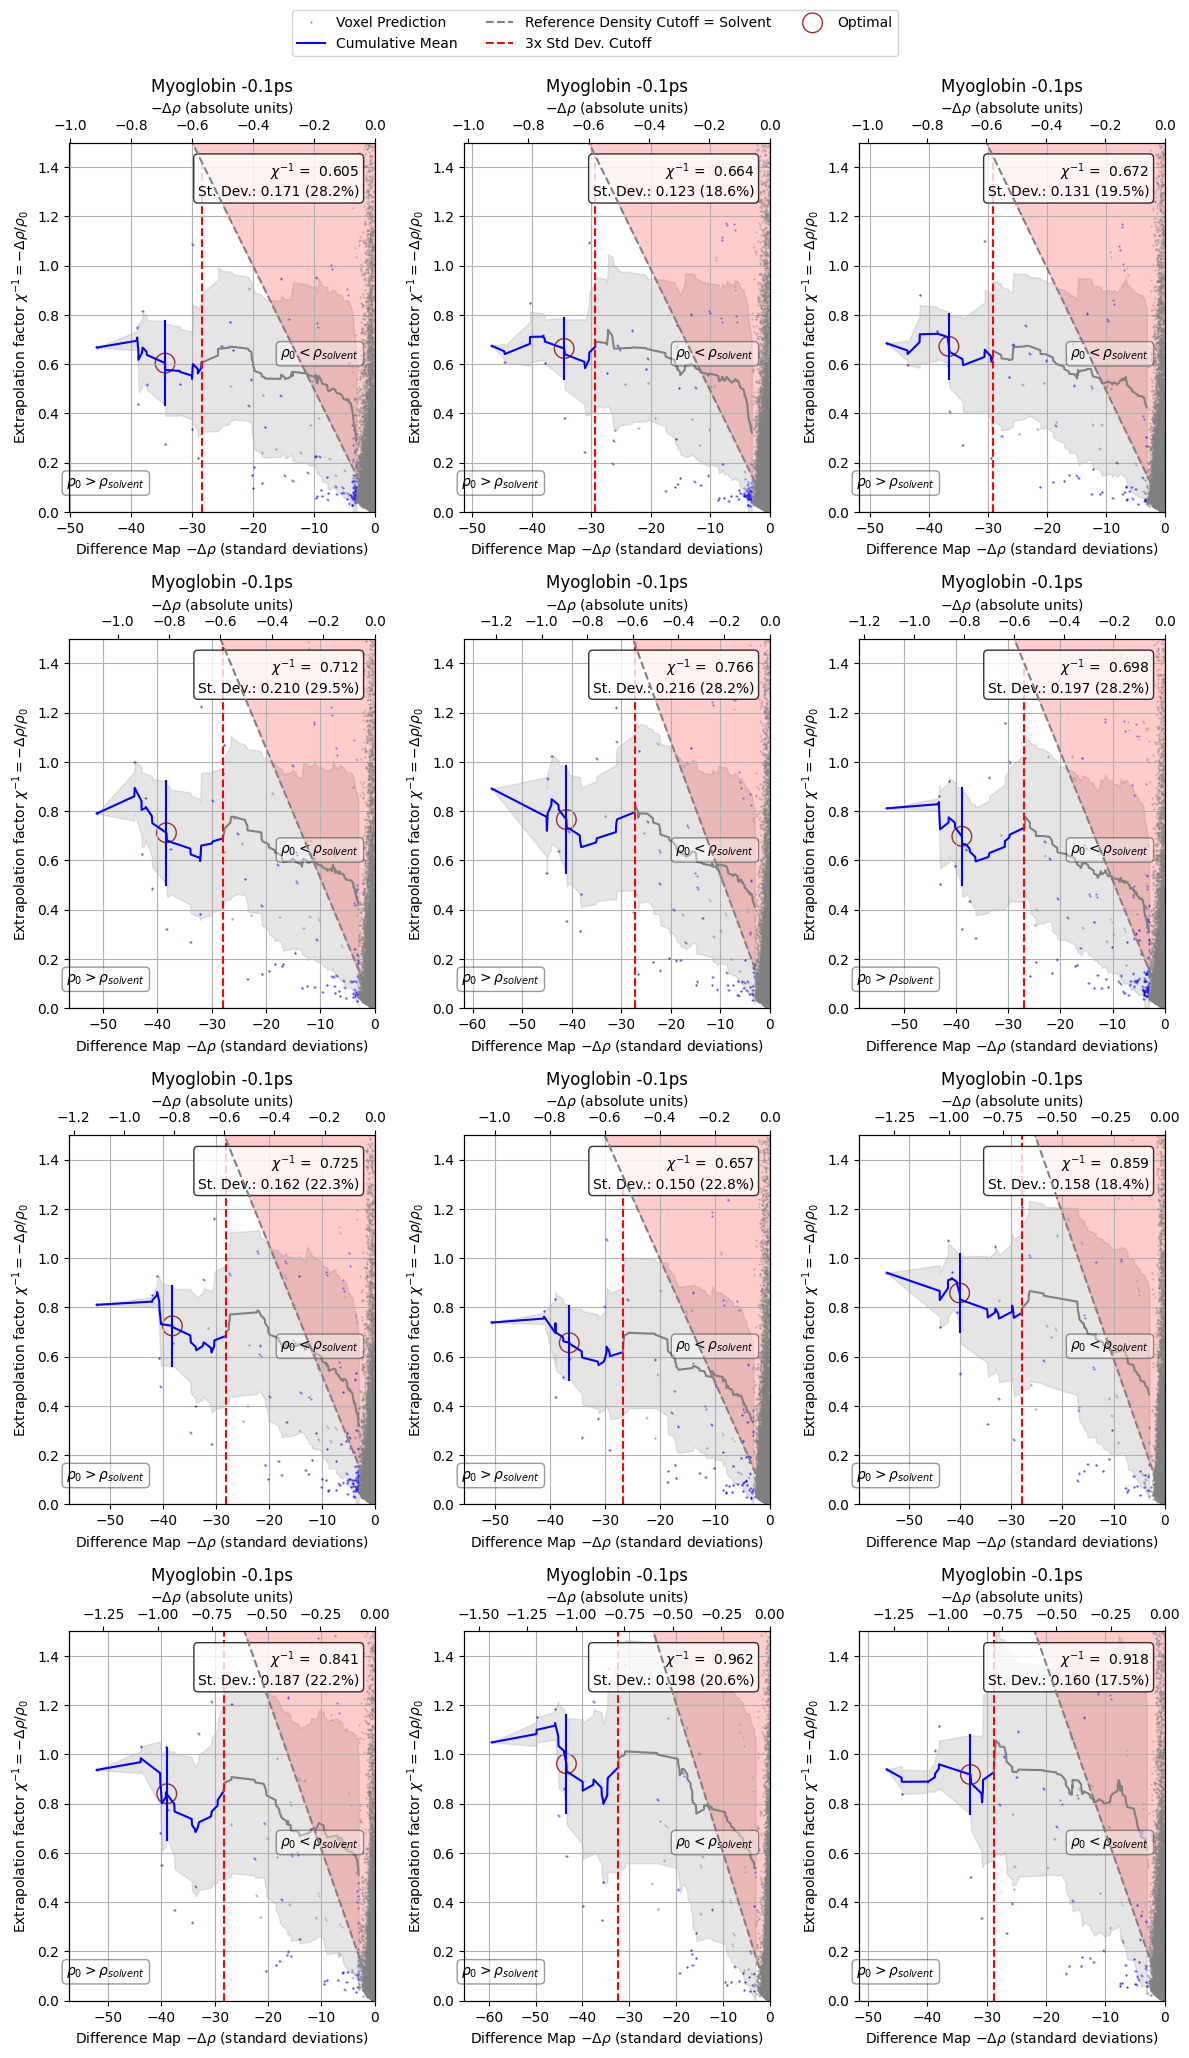

In [12]:
config_overrides = {
    "masking": MaskingSettings.simple().model_dump() | {"dark_size_threshold": 0},
    "map_processing": {"calculate_diffmap_before_f000": True},
}
plot_all_myoglobin(config_overrides=config_overrides)

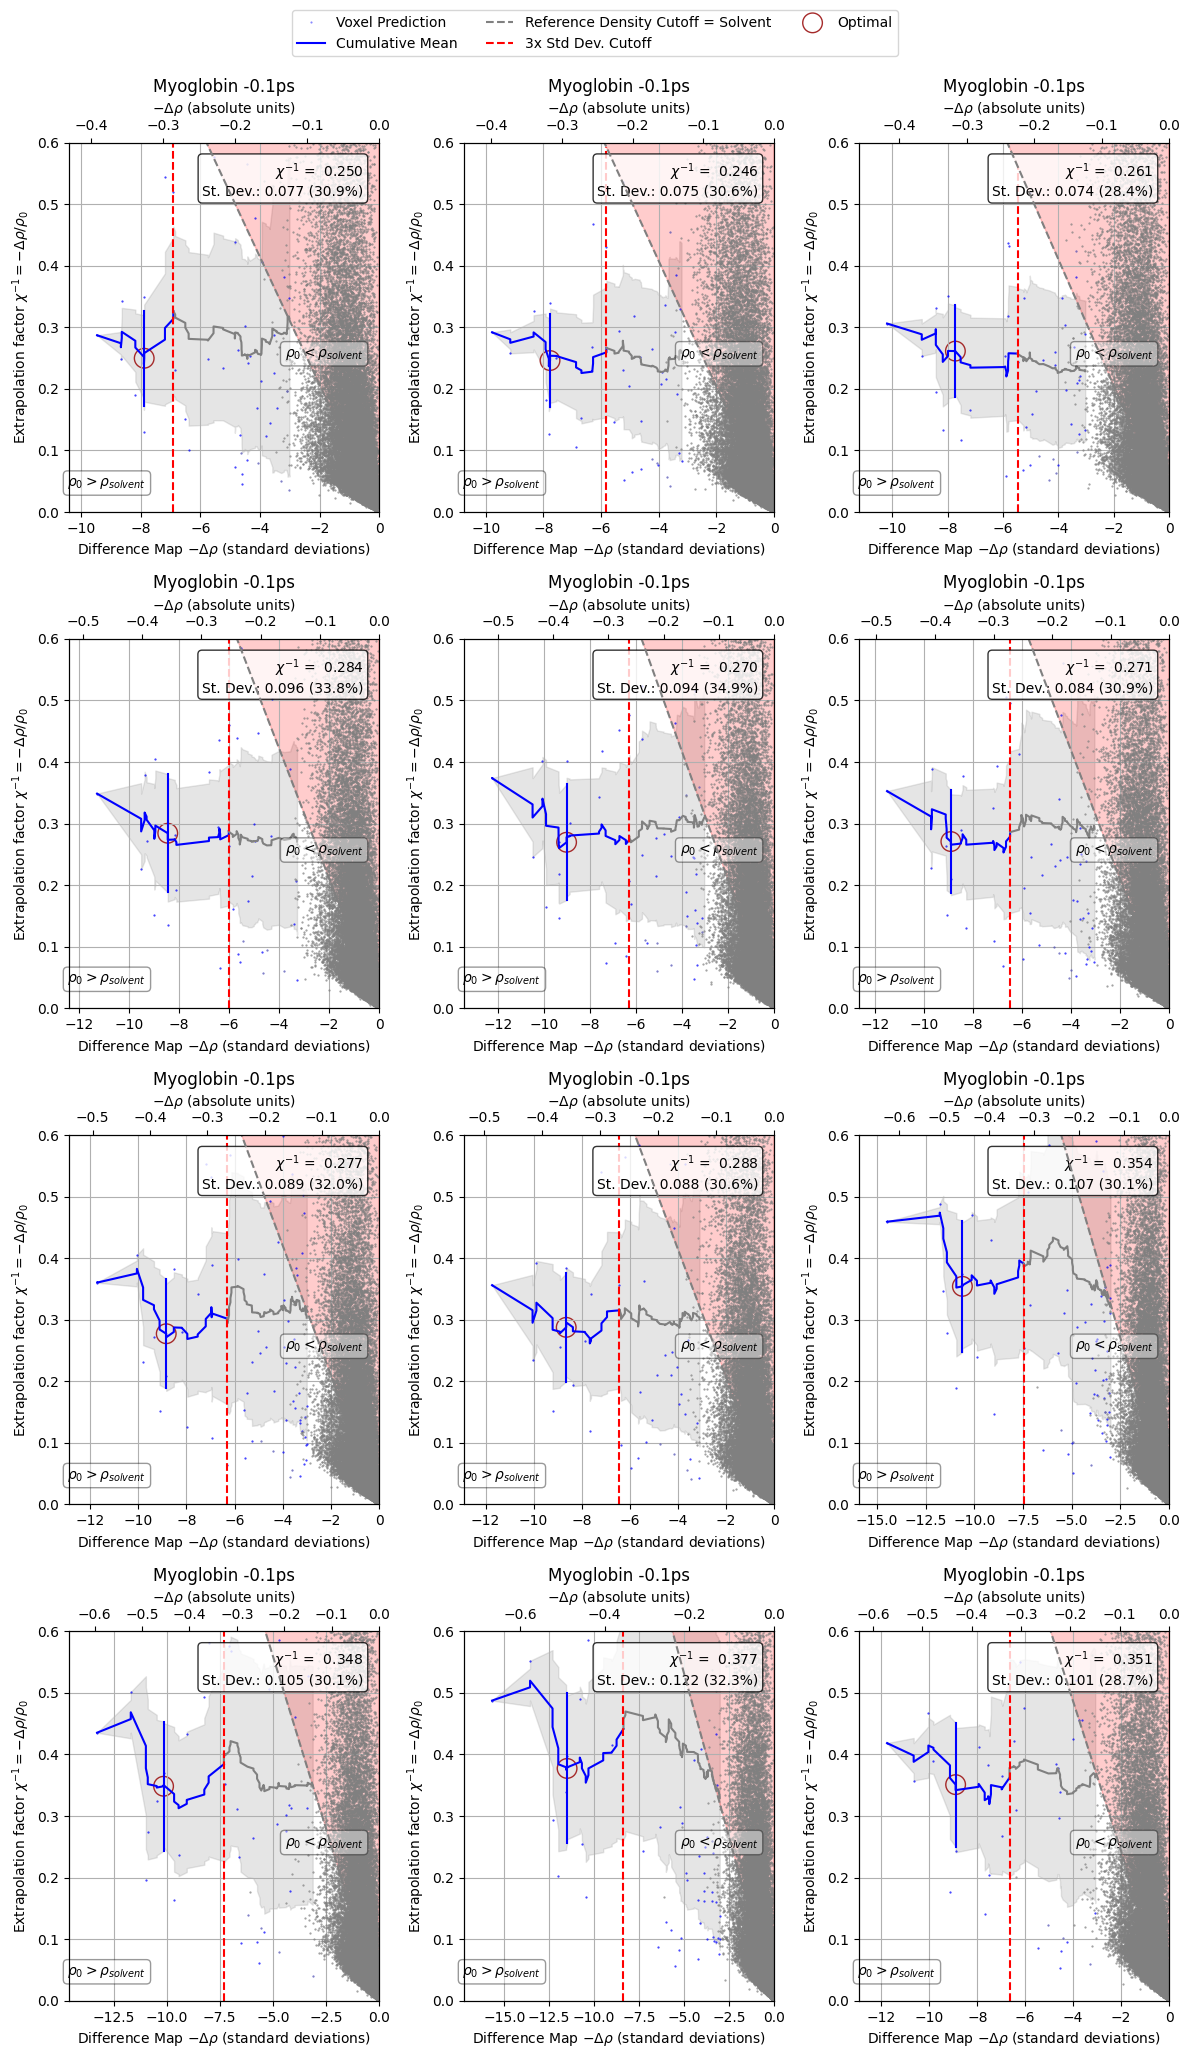

In [ ]:
config_overrides = {
    "masking": {"dark_size_threshold": 0},
    "map_processing": {
        "diffmap_type": "vanilla"
        },
}
plot_all_myoglobin(config_overrides=config_overrides)
